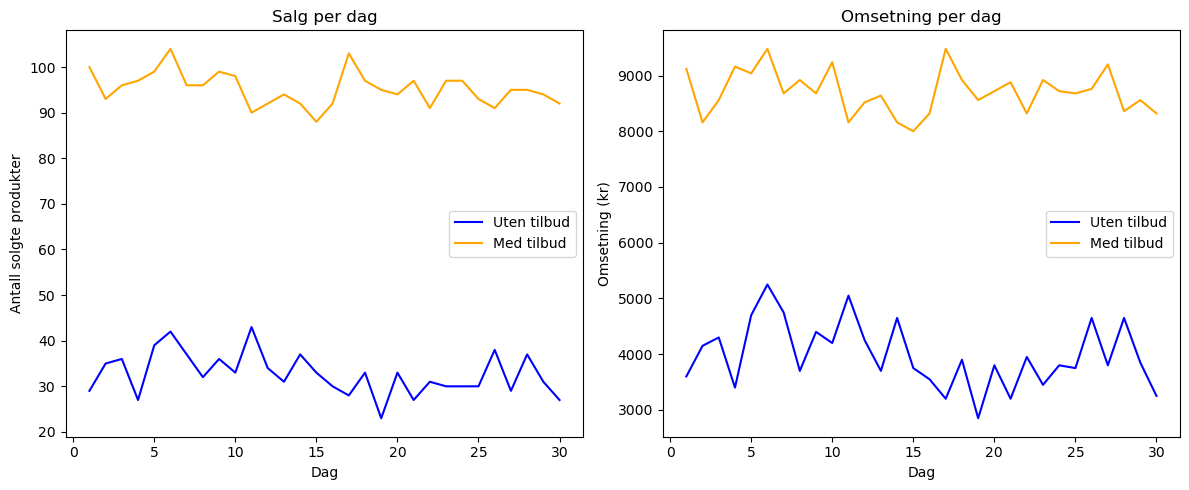

In [1]:
import numpy as np
import matplotlib.pyplot as plt

produkter = [
    {"pris": 100, "salgsjans": 0.2},
    {"pris": 150, "salgsjans": 0.3},
    {"pris": 200, "salgsjans": 0.4},
]

def simuler_dag(antall_kunder, budsjett_mean, budsjett_std, på_tilbud=False, rabatt=0):
    salg, omsetning = 0, 0
    for _ in range(antall_kunder):
        budsjett = np.random.normal(budsjett_mean, budsjett_std)
        for produkt in produkter:
            pris = produkt["pris"] * (1 - rabatt) if på_tilbud else produkt["pris"]
            if np.random.rand() < (produkt["salgsjans"] + (0.5 if på_tilbud else 0)) and budsjett >= pris:
                salg += 1
                omsetning += pris
                budsjett -= pris
    return salg, omsetning

antall_dager, antall_kunder = 30, 100
budsjett_mean, budsjett_std, rabatt = 150, 30, 0.2

# Simuler salg
salg_uten_tilbud, omsetning_uten_tilbud = zip(*[simuler_dag(antall_kunder, budsjett_mean, budsjett_std) for _ in range(antall_dager)])
salg_med_tilbud, omsetning_med_tilbud = zip(*[simuler_dag(antall_kunder, budsjett_mean, budsjett_std, på_tilbud=True, rabatt=rabatt) for _ in range(antall_dager)])

# Visualisering
dager = np.arange(1, antall_dager + 1)

plt.figure(figsize=(12, 5))

# Graf for salg
plt.subplot(1, 2, 1)
plt.plot(dager, salg_uten_tilbud, label='Uten tilbud', color='blue')
plt.plot(dager, salg_med_tilbud, label='Med tilbud', color='orange')
plt.title('Salg per dag')
plt.xlabel('Dag')
plt.ylabel('Antall solgte produkter')
plt.legend()

# Graf for omsetning
plt.subplot(1, 2, 2)
plt.plot(dager, omsetning_uten_tilbud, label='Uten tilbud', color='blue')
plt.plot(dager, omsetning_med_tilbud, label='Med tilbud', color='orange')
plt.title('Omsetning per dag')
plt.xlabel('Dag')
plt.ylabel('Omsetning (kr)')
plt.legend()

plt.tight_layout()
plt.show()